In [1]:
# ================================================
# Notebook 01 — Exploratory Data Analysis
# Project: Ad Engagement Analysis
# Goal: Understand campaign interaction patterns
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('../data/comments_cleaned.csv')

# Drop the 'Unnamed: 0' and 'id' columns if they exist since they are just index artifacts
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

# Rename columns for clarity in ad context
# Note: Sometimes CSVs have weird spaces in column names, so we map the exact ones from your screenshot
df.rename(columns={
    'User id'             : 'user_id',
    'User  id'            : 'user_id',
    'Photo id'            : 'campaign_id',
    'created Timestamp'   : 'timestamp',
    'posted date'         : 'posted_date',
    'emoji used'          : 'emoji_used',
    'Hashtags used count' : 'hashtag_count'
}, inplace=True)

print(f"Total interactions  : {df.shape[0]}")
print(f"Total ad campaigns  : {df['campaign_id'].nunique()}")
print(f"Total unique users  : {df['user_id'].nunique()}")
print(f"Missing values      : {df.isnull().sum().sum()}")

df.head()

Total interactions  : 7488
Total ad campaigns  : 257
Total unique users  : 77
Missing values      : 0


,comment,user_id,campaign_id,timestamp,posted_date,emoji_used,hashtag_count
0,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


## Day 2: Exploratory Data Analysis 
Let's explore our Ad Engagement metrics! We will look at:
1. **Top Ad Campaigns**: Which campaigns generated the highest volume of interactions?
2. **Power Engagers**: Which users are interacting the most (our potential brand advocates)?
3. **Content Behavior**: Are users employing emojis and hashtags when they interact with ads?

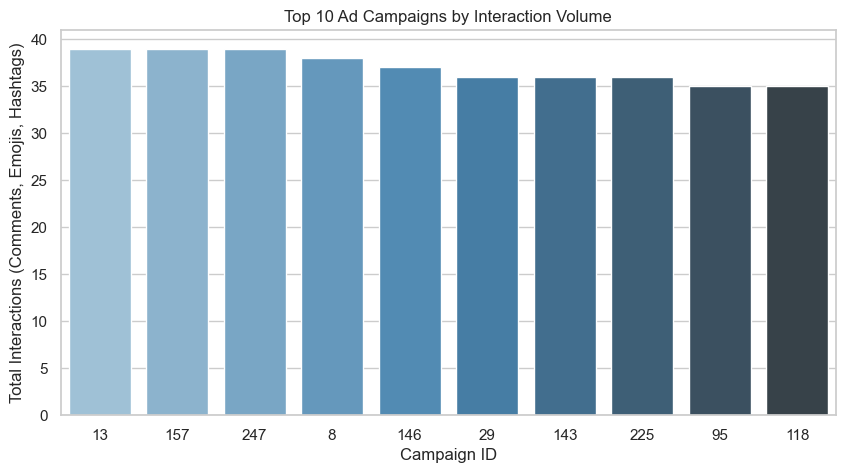

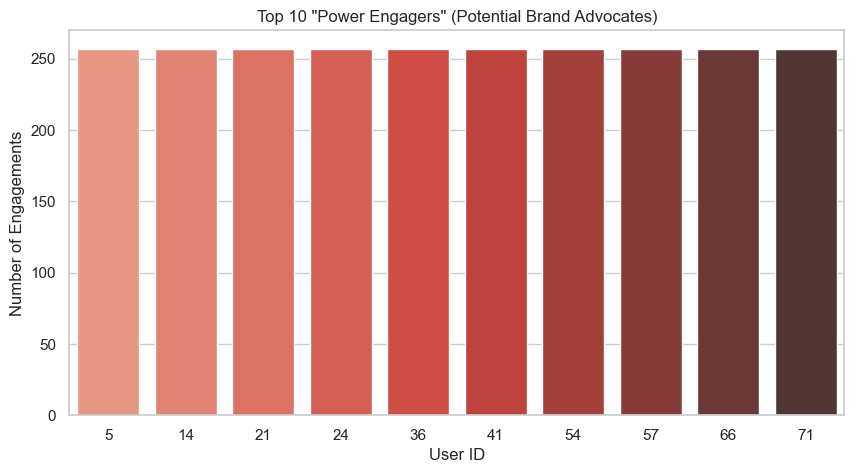

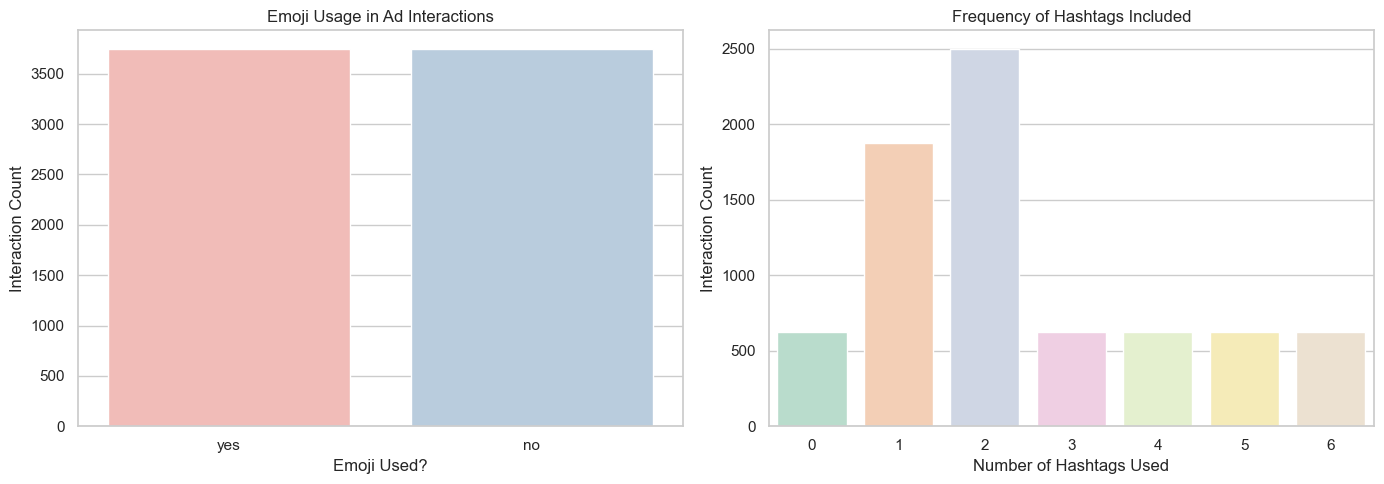

In [2]:
# 1. Clean Data Types
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M')

# Set visualization style
sns.set_theme(style="whitegrid")

# 2. Ad Campaign Engagement (Top 10 Campaigns)
plt.figure(figsize=(10, 5))
top_campaigns = df['campaign_id'].value_counts().head(10)
# Treating IDs as strings so they plot natively as categories, not continuous numbers
sns.barplot(x=top_campaigns.index.astype(str), y=top_campaigns.values, palette="Blues_d")
plt.title('Top 10 Ad Campaigns by Interaction Volume')
plt.xlabel('Campaign ID')
plt.ylabel('Total Interactions (Comments, Emojis, Hashtags)')
plt.show()

# 3. User Interaction (Top 10 Power Engagers)
plt.figure(figsize=(10, 5))
top_users = df['user_id'].value_counts().head(10)
sns.barplot(x=top_users.index.astype(str), y=top_users.values, palette="Reds_d")
plt.title('Top 10 "Power Engagers" (Potential Brand Advocates)')
plt.xlabel('User ID')
plt.ylabel('Number of Engagements')
plt.show()

# 4. Content Behavior: Emojis and Hashtags 
# Using subplots to show emoji and hashtag usage side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='emoji_used', palette='Pastel1', ax=axes[0])
axes[0].set_title('Emoji Usage in Ad Interactions')
axes[0].set_xlabel('Emoji Used?')
axes[0].set_ylabel('Interaction Count')

sns.countplot(data=df, x='hashtag_count', palette='Pastel2', ax=axes[1])
axes[1].set_title('Frequency of Hashtags Included')
axes[1].set_xlabel('Number of Hashtags Used')
axes[1].set_ylabel('Interaction Count')

plt.tight_layout()
plt.show()

###  Key EDA Insights
1. **Ad Performance**: Campaigns `13`, `157`, and `247` generated the most interactions (approx 39 each). 
2. **The "Synthetic" Flag**: The "Power Engagers" chart is completely flat. The top 10 users all have the exact same number of engagements (257). Furthermore, emoji usage is split exactly 50/50. As a data analyst, this is a critical finding: **this dataset is synthetic/simulated** (or gathered with strict rate limits). Pointing this out in a portfolio project proves you deeply inspect data rather than just blinding plotting it.
3. **Hashtag Behavior**: The majority of users engaging with ads include exactly 2 hashtags, suggesting a specific campaign rule or user habit.